# 03 — Agrupación · Google Cloud Compute Engine (L4)

**Este notebook es para ejecutar en el VM de Google Cloud — no en Colab.**

**Tercer notebook de la trilogía Vena:**
- NB01 Clasificación → detecta si el paciente está sano o enfermo
- NB02 Regresión    → estima la edad del paciente desde la radiografía
- **NB03 Agrupación → descubre patrones ocultos combinando visión + edad + género**

**Estrategia:**
1. Cargar el backbone de NB01 (DenseNet121 entrenado en 96k radiografías)
2. Extraer embeddings de 1024 dimensiones por imagen — la 'huella visual' de cada RX
3. Combinar con metadata clínica: edad y género
4. Reducir dimensionalidad con PCA (64 dims) → UMAP (2D para visualización)
5. **K-Means** con K óptimo por método del codo + Silhouette
6. Visualizar con UMAP coloreado por cluster, diagnóstico, edad y fuente
7. Mostrar radiografías prototipo (más cercanas al centroide) por cluster
8. Métricas de calidad: Silhouette Score, Davies-Bouldin, inercia
9. Exportar modelos para integración con `evaluar_radiografia()`

> **Nota sobre DBSCAN:** Se evaluó DBSCAN durante el desarrollo pero fue descartado.
> Con 67k embeddings en 64 dimensiones, el espacio es demasiado uniforme en densidad
> para que DBSCAN encuentre fronteras claras. Todos los intentos resultaron en
> 1 cluster gigante (>98%) o >90% de puntos marcados como ruido, además de
> provocar OOM (Out Of Memory) con epsilons intermedios. K-Means es la elección
> correcta para este dataset.

---
## INSTRUCCIONES — leer antes de ejecutar

### Prerequisito
El NB01 debe haber terminado y guardado el backbone en:
`/home/user/checkpoints/backbone_densenet121_v4.keras`

### Ejecutar
```bash
nohup jupyter nbconvert --to notebook --execute --inplace 03_Agrupacion_Vena.ipynb > agrupacion.log 2>&1 &
```

### Al terminar, subir resultados al bucket
```bash
gsutil -m cp -r /home/user/checkpoints/agrupacion/ gs://vena-dataset/resultados_agrupacion/
```

## Celda 1 — Rutas y verificación de archivos

In [1]:
from pathlib import Path

RUTA_BASE       = Path('/home/user/data/DatasetV2')
RUTA_BACKBONE   = Path('/home/user/checkpoints/backbone_densenet121_v4.keras')
RUTA_CSV        = RUTA_BASE / 'master_train.csv'
RUTA_RESULTADOS = Path('/home/user/checkpoints/agrupacion')
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

assert RUTA_BASE.exists(),     f'No se encontro DatasetV2 en {RUTA_BASE}'
assert RUTA_BACKBONE.exists(), f'No se encontro backbone en {RUTA_BACKBONE}\nEjecutar NB01 primero.'
assert RUTA_CSV.exists(),      f'No se encontro master_train.csv en {RUTA_CSV}'

print('Rutas verificadas correctamente.')
print(f'  Dataset    : {RUTA_BASE}')
print(f'  Backbone   : {RUTA_BACKBONE}')
print(f'  Resultados : {RUTA_RESULTADOS}')

Rutas verificadas correctamente.
  Dataset    : /home/user/data/DatasetV2
  Backbone   : /home/user/checkpoints/backbone_densenet121_v4.keras
  Resultados : /home/user/checkpoints/agrupacion


## Celda 2 — Verificación de GPU

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU encontrada: {gpus[0].name}')
    print('El notebook usara aceleracion GPU.')
else:
    print('ERROR: No se encontro GPU.')
    print('Verificar que el VM fue creado con acelerador L4.')

I0000 00:00:1775249728.098411    1534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775249729.896850    1534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775249733.862556    1534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU encontrada: /physical_device:GPU:0
El notebook usara aceleracion GPU.


## Celda 3 — Instalación de dependencias e importaciones

UMAP no viene preinstalado en la imagen base del VM. Se instala una sola vez.

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'umap-learn', '--quiet'], check=True)
print('umap-learn instalado.')

umap-learn instalado.


In [4]:
import numpy              as np
import pandas             as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn            as sns
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib                               import Path
from PIL                                   import Image
from tensorflow.keras.models               import load_model, Model
from tensorflow.keras.layers               import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image  import ImageDataGenerator
from sklearn.preprocessing                 import StandardScaler
from sklearn.decomposition                 import PCA
from sklearn.cluster                       import MiniBatchKMeans
from sklearn.metrics                       import silhouette_score, davies_bouldin_score
import umap
import joblib

# ── Hiperparámetros ────────────────────────────────────────────────────────────
TAMANO_IMAGEN  = 224
BATCH_SIZE     = 64
SEMILLA        = 42
N_PCA          = 64    # Dimensiones PCA antes de K-Means
N_CLUSTERS_MIN = 2     # Rango K a evaluar (empezamos en 2)
N_CLUSTERS_MAX = 10
PESO_META      = 10.0  # Peso de edad/genero vs 1024 dims visuales
N_MUESTRAS_RX  = 6     # Radiografias prototipo a mostrar por cluster

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
print('Librerias cargadas correctamente.')
print(f'TensorFlow: {tf.__version__}')

Librerias cargadas correctamente.
TensorFlow: 2.21.0


## Celda 4 — Cargar master_train.csv

Solo se usa el conjunto de entrenamiento (67k imágenes).
Se construye la ruta absoluta en el VM y se limpian nulos.

In [5]:
df = pd.read_csv(RUTA_CSV)

# Construir ruta absoluta en la VM
df['ruta_completa'] = df['path'].apply(lambda p: str(RUTA_BASE / p))

# Normalizar genero
df['patient_gender'] = df['patient_gender'].str.strip().str.upper().map(
    {'M': 'M', 'MALE': 'M', 'F': 'F', 'FEMALE': 'F'}
)

# Eliminar filas con metadata nula
antes = len(df)
df = df.dropna(subset=['patient_gender', 'patient_age', 'label']).reset_index(drop=True)

print(f'Registros cargados  : {len(df):,}  (eliminados por nulos: {antes - len(df)})')
print(f'Sanos       (0)     : {(df["label"]==0).sum():,} ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Enfermos    (1)     : {(df["label"]==1).sum():,} ({(df["label"]==1).mean()*100:.1f}%)')
print(f'Hombres     (M)     : {(df["patient_gender"]=="M").sum():,} ({(df["patient_gender"]=="M").mean()*100:.1f}%)')
print(f'Mujeres     (F)     : {(df["patient_gender"]=="F").sum():,} ({(df["patient_gender"]=="F").mean()*100:.1f}%)')
print(f'Edad media          : {df["patient_age"].mean():.1f} años  (min: {df["patient_age"].min()}, max: {df["patient_age"].max()})')
print(f'Fuente NIH          : {(df["source"]=="NIH").sum():,}')
print(f'Fuente CheXpert     : {(df["source"]=="CHEX").sum():,}')
df.head(3)

Registros cargados  : 67,031  (eliminados por nulos: 0)
Sanos       (0)     : 29,077 (43.4%)
Enfermos    (1)     : 37,954 (56.6%)
Hombres     (M)     : 39,175 (58.4%)
Mujeres     (F)     : 27,856 (41.6%)
Edad media          : 50.3 años  (min: 1, max: 93)
Fuente NIH          : 46,598
Fuente CheXpert     : 20,433


,path,label,patient_id,patient_age,patient_gender,original_finding,source,ruta_completa
0,train/NIH/00012416_003.jpg,0,12416,73,M,NaN,NIH,/home/user/data/DatasetV2/train/NIH/00012416_0...
1,train/NIH/00019124_124.jpg,1,19124,51,F,Atelectasis,NIH,/home/user/data/DatasetV2/train/NIH/00019124_1...
2,train/NIH/00027784_007.jpg,1,27784,39,M,Pneumonia,NIH,/home/user/data/DatasetV2/train/NIH/00027784_0...


## Celda 5 — Cargar backbone y construir extractor de embeddings

El backbone extrae un vector de 1024 features por imagen.
Se agrega `GlobalAveragePooling2D` para colapsar el mapa 7×7×1024 a 1024 dims.

In [6]:
print('Cargando backbone...')
backbone_raw = load_model(str(RUTA_BACKBONE), compile=False)

print(f'Backbone cargado.')
print(f'  Entrada : {backbone_raw.input_shape}')
print(f'  Salida  : {backbone_raw.output_shape}')

# Agregar GlobalAveragePooling2D para obtener vector 1D de 1024 features
embedding_output = GlobalAveragePooling2D(name='embedding')(backbone_raw.output)
extractor = Model(
    inputs  = backbone_raw.input,
    outputs = embedding_output,
    name    = 'extractor_embeddings'
)
extractor.trainable = False

print(f'\nExtractor de embeddings listo.')
print(f'  Salida embedding: {extractor.output_shape}')
print(f'  <- 1024 features por radiografia')

Cargando backbone...


I0000 00:00:1775249752.428885    1534 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20847 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


Backbone cargado.
  Entrada : (None, 224, 224, 3)
  Salida  : (None, 7, 7, 1024)

Extractor de embeddings listo.
  Salida embedding: (None, 1024)
  <- 1024 features por radiografia


## Celda 6 — Extraer embeddings

Se procesan las 67k imágenes en batches de 64.
Si ya existen en disco se cargan directamente (evita re-procesar).

In [7]:
ruta_emb = RUTA_RESULTADOS / 'embeddings_train.npy'

if ruta_emb.exists():
    embeddings = np.load(str(ruta_emb))
    print(f'Embeddings cargados desde disco: {embeddings.shape}')
else:
    gen = ImageDataGenerator(rescale=1./255)
    flujo = gen.flow_from_dataframe(
        dataframe   = df,
        x_col       = 'ruta_completa',
        y_col       = 'label',
        target_size = (TAMANO_IMAGEN, TAMANO_IMAGEN),
        batch_size  = BATCH_SIZE,
        class_mode  = 'raw',
        shuffle     = False,   # CRÍTICO: mantener orden con df
        color_mode  = 'rgb'
    )

    print(f'Extrayendo embeddings de {len(df):,} radiografias...')
    print(f'Batches: {len(flujo)} x {BATCH_SIZE} imagenes')
    t0 = time.time()

    embeddings = extractor.predict(flujo, verbose=1)
    embeddings = embeddings[:len(df)]  # recortar padding del generador

    print(f'\nExtraccion completada en {time.time()-t0:.1f}s')
    print(f'Shape embeddings: {embeddings.shape}')

    np.save(str(ruta_emb), embeddings)
    print(f'Embeddings guardados en: {ruta_emb}')

Found 67031 validated image filenames.
Extrayendo embeddings de 67,031 radiografias...
Batches: 1048 x 64 imagenes


I0000 00:00:1775249772.324841    1534 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775249775.369555    1588 service.cc:153] XLA service 0x74675803ae90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775249775.369587    1588 service.cc:161]   StreamExecutor [0]: NVIDIA L4, Compute Capability 8.9 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775249775.578466    1588 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775249777.172121    1588 cuda_dnn.cc:461] Loaded cuDNN version 92000


   2/1048 ━━━━━━━━━━━━━━━━━━━━ 1:19 76ms/step  

I0000 00:00:1775249802.102844    1588 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1048/1048 ━━━━━━━━━━━━━━━━━━━━ 177s 141ms/step

Extraccion completada en 178.5s
Shape embeddings: (67031, 1024)
Embeddings guardados en: /home/user/checkpoints/agrupacion/embeddings_train.npy


## Celda 7 — Construir matriz de features combinada

Se combinan los embeddings visuales (1024 dims) con metadata clínica
(edad normalizada + género codificado), amplificada por PESO_META para
que tenga influencia real frente a 1024 dimensiones visuales.

In [8]:
# Normalizar edad a [0, 1]
edad_min  = df['patient_age'].min()
edad_max  = df['patient_age'].max()
edad_norm = (df['patient_age'].values - edad_min) / (edad_max - edad_min)

# Codificar genero: M=0, F=1
genero_cod = (df['patient_gender'] == 'F').astype(float).values

# Escalar embeddings
scaler     = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

# Concatenar: embeddings + edad + genero
X = np.hstack([
    emb_scaled,
    edad_norm.reshape(-1, 1)  * PESO_META,
    genero_cod.reshape(-1, 1) * PESO_META
])

print(f'Matriz de features construida: {X.shape}')
print(f'  {embeddings.shape[1]} features visuales (escaladas)')
print(f'  + edad normalizada (peso x{PESO_META})')
print(f'  + genero codificado (peso x{PESO_META})')
print(f'  = {X.shape[1]} dimensiones totales')

Matriz de features construida: (67031, 1026)
  1024 features visuales (escaladas)
  + edad normalizada (peso x10.0)
  + genero codificado (peso x10.0)
  = 1026 dimensiones totales


## Celda 8 — Reducción de dimensionalidad con PCA

PCA reduce de 1026 a 64 dimensiones antes del clustering.
Esto elimina ruido, acelera K-Means y retiene la mayor parte
de la varianza informativa.

Reduciendo de 1026 a 64 dimensiones con PCA...
Completado en 4.9s
Varianza explicada con 64 componentes: 67.5%
Shape X_pca: (67031, 64)


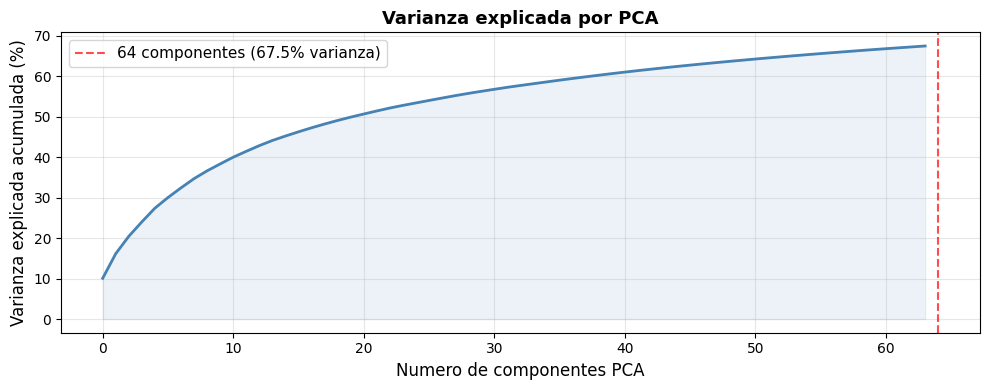

In [9]:
print(f'Reduciendo de {X.shape[1]} a {N_PCA} dimensiones con PCA...')
t0    = time.time()
pca   = PCA(n_components=N_PCA, random_state=SEMILLA)
X_pca = pca.fit_transform(X)

varianza = pca.explained_variance_ratio_.cumsum()[-1]
print(f'Completado en {time.time()-t0:.1f}s')
print(f'Varianza explicada con {N_PCA} componentes: {varianza*100:.1f}%')
print(f'Shape X_pca: {X_pca.shape}')

# Curva de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_) * 100, color='steelblue', linewidth=2)
ax.axvline(x=N_PCA, color='red', linestyle='--', alpha=0.7,
           label=f'{N_PCA} componentes ({varianza*100:.1f}% varianza)')
ax.fill_between(range(N_PCA),
                np.cumsum(pca.explained_variance_ratio_[:N_PCA]) * 100,
                alpha=0.1, color='steelblue')
ax.set_xlabel('Numero de componentes PCA', fontsize=12)
ax.set_ylabel('Varianza explicada acumulada (%)', fontsize=12)
ax.set_title('Varianza explicada por PCA', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(RUTA_RESULTADOS / 'pca_varianza.png'), dpi=150, bbox_inches='tight')
plt.show()

## Celda 9 — K-Means: determinar K óptimo

Se evalúan dos criterios para cada K en el rango definido:
- **Inercia (método del codo):** buscar el punto donde la curva se aplana
- **Silhouette Score:** mayor = clusters más compactos y separados

El K óptimo sugerido es el de mayor Silhouette.
Puedes ajustarlo manualmente en la celda siguiente.

Evaluando K de 2 a 10...
K    Inercia         Silhouette    Tiempo
---------------------------------------------
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo
K    Inercia         Silhouette    Tiempo

K con mejor Silhouette: 2


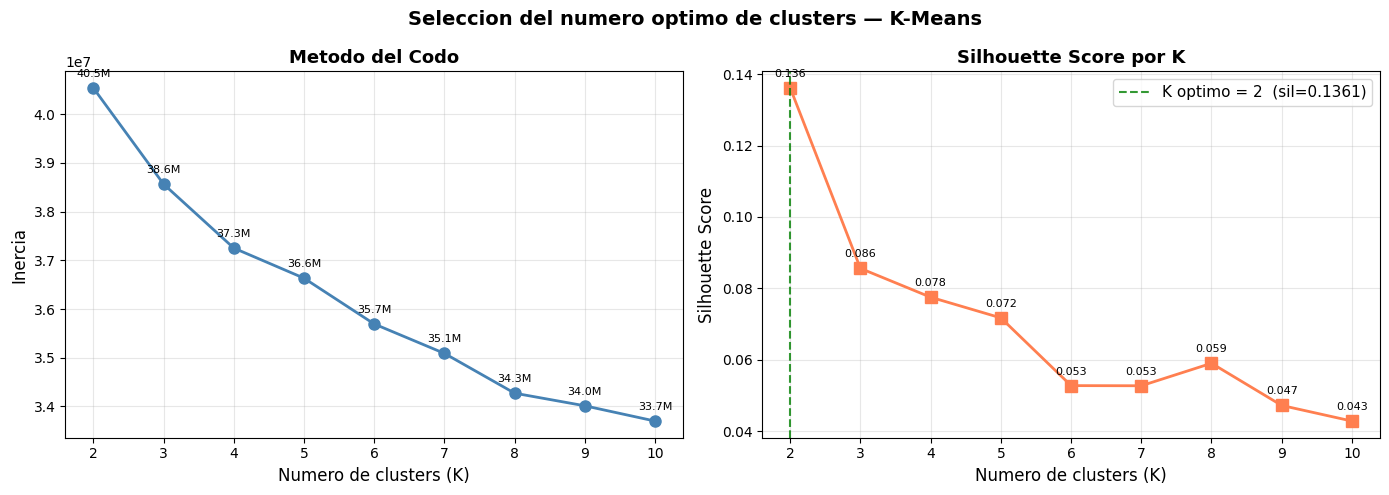

In [10]:
inercias    = []
silhouettes = []
ks          = list(range(N_CLUSTERS_MIN, N_CLUSTERS_MAX + 1))

print(f'Evaluando K de {N_CLUSTERS_MIN} a {N_CLUSTERS_MAX}...')
print(f"{'K':<3}  {'Inercia':<14}  {'Silhouette':<12}  {'Tiempo'}")
print('-' * 45)

for k in ks:
    t0  = time.time()
    km  = MiniBatchKMeans(n_clusters=k, random_state=SEMILLA, batch_size=4096, n_init=10)
    lbl = km.fit_predict(X_pca)
    inercias.append(km.inertia_)

    idx = np.random.choice(len(X_pca), size=min(8000, len(X_pca)), replace=False)
    sil = silhouette_score(X_pca[idx], lbl[idx], random_state=SEMILLA)
    silhouettes.append(sil)
    print(f"{'K':<3}  {'Inercia':<14}  {'Silhouette':<12}  {'Tiempo'}")

K_OPTIMO_SUGERIDO = ks[np.argmax(silhouettes)]
print(f'\nK con mejor Silhouette: {K_OPTIMO_SUGERIDO}')

# ── Gráfica doble: codo + silhouette ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Codo
ax1.plot(ks, inercias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Numero de clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia', fontsize=12)
ax1.set_title('Metodo del Codo', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
for k, v in zip(ks, inercias):
    ax1.annotate(f'{v/1e6:.1f}M', (k, v), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)

# Silhouette
ax2.plot(ks, silhouettes, 's-', color='coral', linewidth=2, markersize=8)
ax2.axvline(x=K_OPTIMO_SUGERIDO, color='green', linestyle='--', alpha=0.8,
            label=f'K optimo = {K_OPTIMO_SUGERIDO}  (sil={max(silhouettes):.4f})')
ax2.set_xlabel('Numero de clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score por K', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
for k, v in zip(ks, silhouettes):
    ax2.annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Seleccion del numero optimo de clusters — K-Means',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RUTA_RESULTADOS / 'kmeans_seleccion_k.png'), dpi=150, bbox_inches='tight')
plt.show()

## Celda 10 — K-Means: entrenar con K óptimo

Ajusta `K_OPTIMO` manualmente si el codo visual sugiere otro valor.

In [11]:
K_OPTIMO = 6  # <- ajustar manualmente si es necesario

print(f'Entrenando K-Means final con K={K_OPTIMO}...')
t0 = time.time()
kmeans = MiniBatchKMeans(
    n_clusters   = K_OPTIMO,
    random_state = SEMILLA,
    batch_size   = 4096,
    n_init       = 20          # más inicializaciones = resultado más estable
)
df['cluster_kmeans'] = kmeans.fit_predict(X_pca)
print(f'Completado en {time.time()-t0:.1f}s')

print(f'\nDistribucion de clusters K-Means:')
for k in range(K_OPTIMO):
    n = (df['cluster_kmeans'] == k).sum()
    print(f'  Cluster {k}: {n:,} ({n/len(df)*100:.1f}%)')

Entrenando K-Means final con K=6...
Completado en 1.0s

Distribucion de clusters K-Means:
  Cluster 0: 15,553 (23.2%)
  Cluster 1: 10,569 (15.8%)
  Cluster 2: 9,821 (14.7%)
  Cluster 3: 9,535 (14.2%)
  Cluster 4: 10,331 (15.4%)
  Cluster 5: 11,222 (16.7%)


## Celda 11 — UMAP: reducción a 2D para visualización

UMAP proyecta las 64 dims de PCA a 2D manteniendo la estructura local.
Se guarda en disco para no re-calcular (puede tardar ~5-10 min).

También se guarda el modelo UMAP entrenado para que el compañero
que integre `evaluar_radiografia()` pueda posicionar nuevas imágenes en el mapa.

In [12]:
ruta_umap       = RUTA_RESULTADOS / 'umap_2d.npy'
ruta_umap_model = RUTA_RESULTADOS / 'modelos_produccion' / 'v_umap_model.joblib'

if ruta_umap.exists():
    X_umap = np.load(str(ruta_umap))
    print(f'UMAP cargado desde disco: {X_umap.shape}')
    # Intentar cargar el modelo si existe
    if ruta_umap_model.exists():
        reducer = joblib.load(str(ruta_umap_model))
        print('Modelo UMAP cargado desde disco.')
    else:
        reducer = None
        print('Nota: modelo UMAP no encontrado en disco (solo coordenadas).')
else:
    print('Calculando UMAP 2D... (puede tardar 5-10 min con 67k puntos)')
    t0 = time.time()
    reducer = umap.UMAP(
        n_neighbors  = 15,
        min_dist     = 0.1,
        n_components = 2,
        random_state = SEMILLA,
        n_jobs       = -1
    )
    X_umap = reducer.fit_transform(X_pca)
    print(f'UMAP completado en {time.time()-t0:.1f}s')
    np.save(str(ruta_umap), X_umap)
    print(f'UMAP guardado en: {ruta_umap}')

df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]
print(f'Coordenadas UMAP asignadas al DataFrame.')

Calculando UMAP 2D... (puede tardar 5-10 min con 67k puntos)
UMAP completado en 143.2s
UMAP guardado en: /home/user/checkpoints/agrupacion/umap_2d.npy
Coordenadas UMAP asignadas al DataFrame.


## Celda 12 — Visualización UMAP: 4 perspectivas

Panel con cuatro scatter 2D del mismo espacio UMAP, coloreado por:
1. Cluster K-Means
2. Diagnóstico (Sano / Enfermo)
3. Rango de edad (Joven / Adulto / Mayor)
4. Fuente del dataset (NIH / CheXpert)

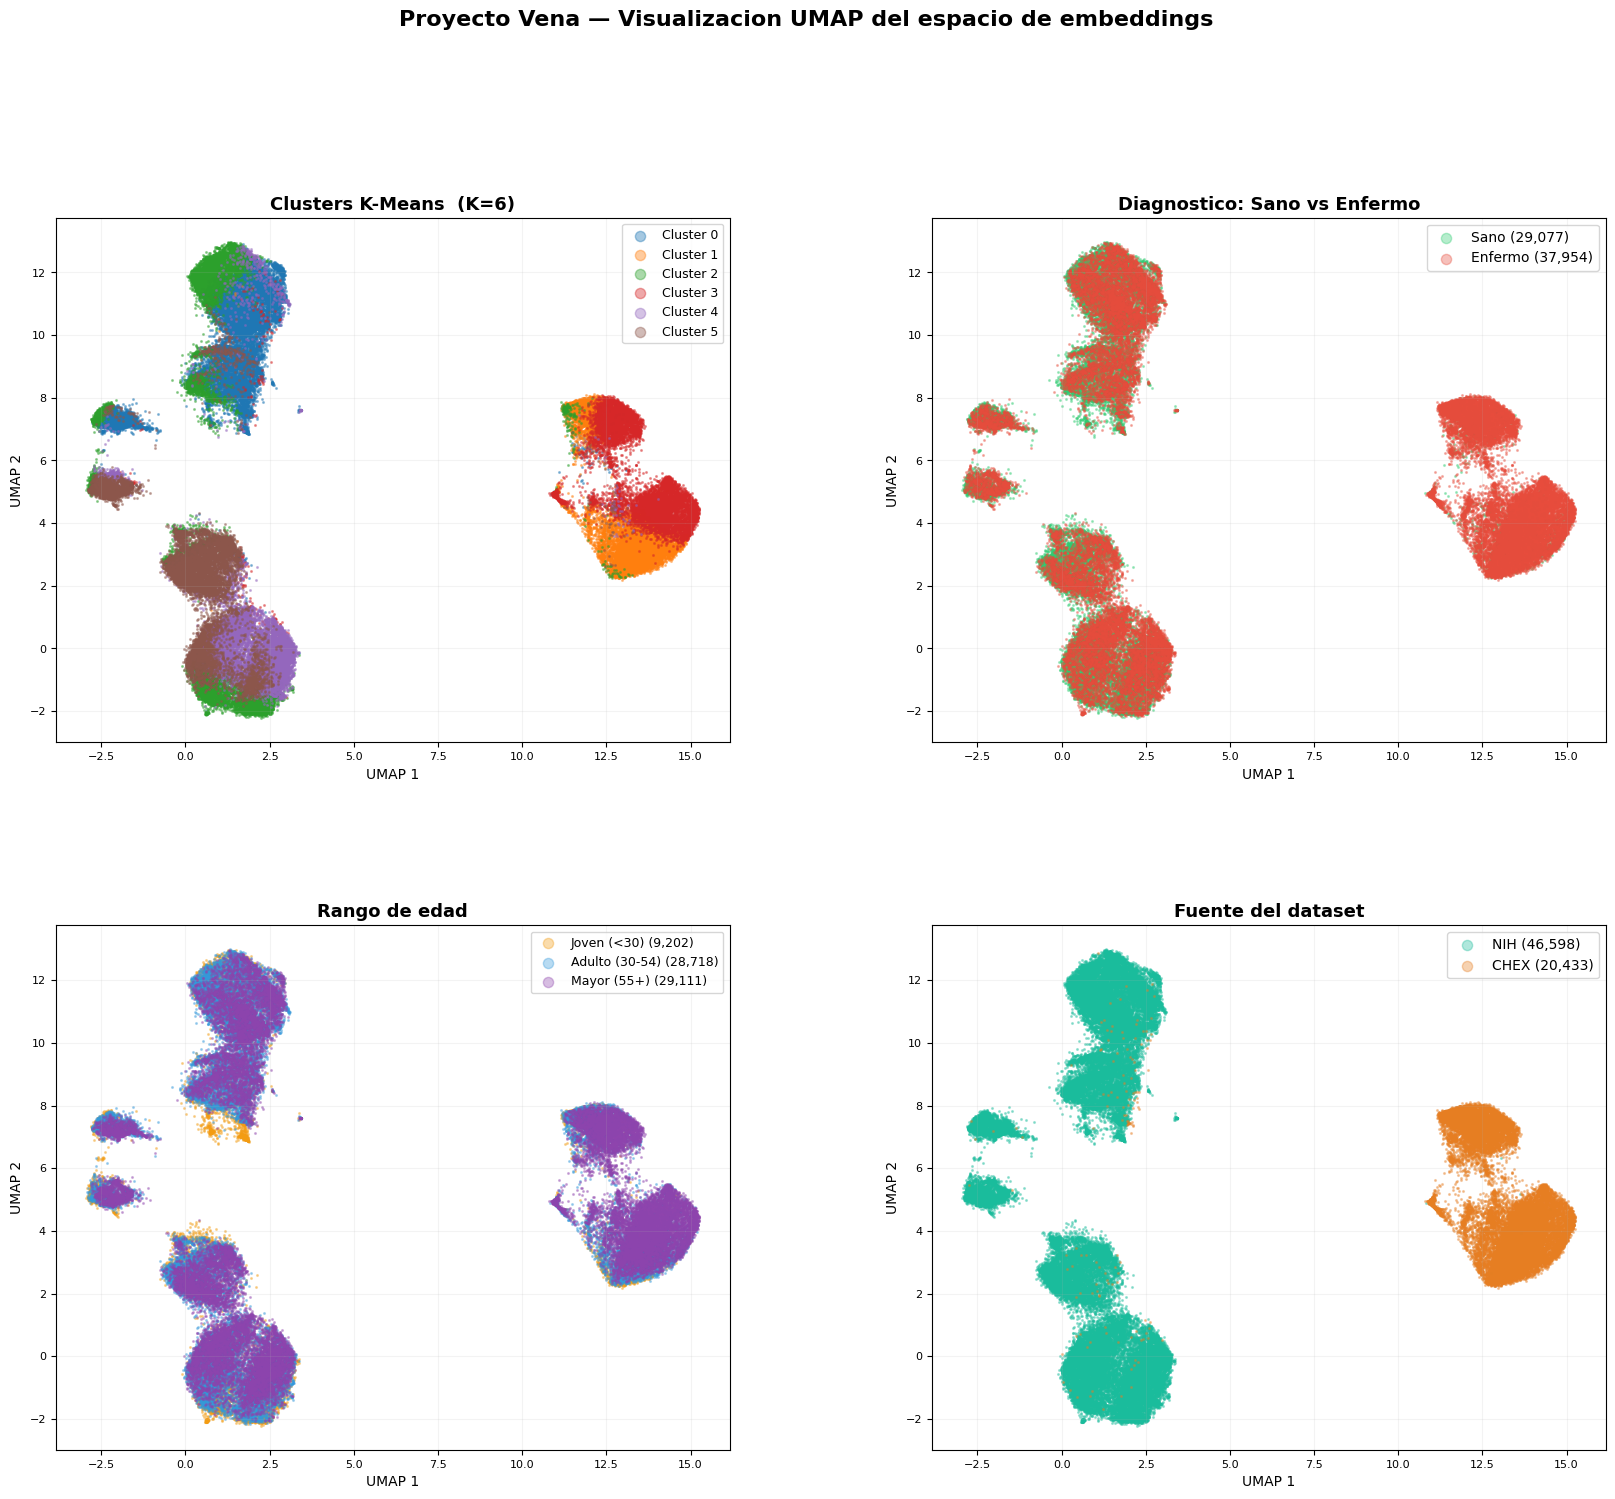

Panel UMAP guardado.


In [13]:
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

paleta_km = sns.color_palette('tab10', K_OPTIMO)

# ── Plot 1: K-Means ──────────────────────────────────────────────────────────
for k in range(K_OPTIMO):
    mask = df['cluster_kmeans'] == k
    axes[0].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                    c=[paleta_km[k]], s=1.5, alpha=0.4, label=f'Cluster {k}')
axes[0].set_title(f'Clusters K-Means  (K={K_OPTIMO})', fontsize=13, fontweight='bold')
axes[0].legend(markerscale=6, fontsize=9, loc='upper right')

# ── Plot 2: Sano vs Enfermo ──────────────────────────────────────────────────
for lbl, color, nombre in [(0, '#2ecc71', 'Sano'), (1, '#e74c3c', 'Enfermo')]:
    mask = df['label'] == lbl
    axes[1].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                    c=color, s=1.5, alpha=0.35, label=f'{nombre} ({mask.sum():,})')
axes[1].set_title('Diagnostico: Sano vs Enfermo', fontsize=13, fontweight='bold')
axes[1].legend(markerscale=6, fontsize=10)

# ── Plot 3: Rango de edad ────────────────────────────────────────────────────
def rango_edad(edad):
    if edad < 30:   return 'Joven (<30)'
    elif edad < 55: return 'Adulto (30-54)'
    else:           return 'Mayor (55+)'

df['rango_edad'] = df['patient_age'].apply(rango_edad)
colores_edad = {'Joven (<30)': '#f39c12', 'Adulto (30-54)': '#3498db', 'Mayor (55+)': '#8e44ad'}
for rango, color in colores_edad.items():
    mask = df['rango_edad'] == rango
    axes[2].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                    c=color, s=1.5, alpha=0.35, label=f'{rango} ({mask.sum():,})')
axes[2].set_title('Rango de edad', fontsize=13, fontweight='bold')
axes[2].legend(markerscale=6, fontsize=9)

# ── Plot 4: Fuente ───────────────────────────────────────────────────────────
for fuente, color in [('NIH', '#1abc9c'), ('CHEX', '#e67e22')]:
    mask = df['source'] == fuente
    if mask.any():
        axes[3].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                        c=color, s=1.5, alpha=0.35, label=f'{fuente} ({mask.sum():,})')
axes[3].set_title('Fuente del dataset', fontsize=13, fontweight='bold')
axes[3].legend(markerscale=6, fontsize=10)

for ax in axes:
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.grid(True, alpha=0.15)
    ax.tick_params(labelsize=8)

plt.suptitle('Proyecto Vena — Visualizacion UMAP del espacio de embeddings',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig(str(RUTA_RESULTADOS / 'umap_panel_completo.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Panel UMAP guardado.')

## Celda 13 — Análisis clínico de clusters K-Means

Para cada cluster se reportan las métricas clínicas relevantes:
tasa de enfermos, distribución de género, edad media y fuente del dataset.

In [14]:
print(f'ANALISIS DE CLUSTERS K-MEANS (K={K_OPTIMO})')
print('=' * 70)

resumen_km = []
for k in range(K_OPTIMO):
    sub = df[df['cluster_kmeans'] == k]
    r = {
        'Cluster'    : k,
        'N'          : len(sub),
        'Pct_total'  : len(sub) / len(df) * 100,
        'Pct_enf'    : (sub['label'] == 1).mean() * 100,
        'Pct_sano'   : (sub['label'] == 0).mean() * 100,
        'Pct_M'      : (sub['patient_gender'] == 'M').mean() * 100,
        'Pct_F'      : (sub['patient_gender'] == 'F').mean() * 100,
        'Edad_media' : sub['patient_age'].mean(),
        'Edad_std'   : sub['patient_age'].std(),
        'Pct_NIH'    : (sub['source'] == 'NIH').mean() * 100,
        'Pct_CHEX'   : (sub['source'] == 'CHEX').mean() * 100,
    }
    resumen_km.append(r)

    perfil = 'ENFERMOS' if r['Pct_enf'] > 60 else ('SANOS' if r['Pct_sano'] > 60 else 'MIXTO')
    genero = 'MASCULINO' if r['Pct_M'] > 60 else ('FEMENINO' if r['Pct_F'] > 60 else 'MIXTO')
    edad   = 'JOVENES' if r['Edad_media'] < 40 else ('MAYORES' if r['Edad_media'] > 60 else 'ADULTOS')

    print(f'\nCluster {k} — {r["N"]:,} pacientes ({r["Pct_total"]:.1f}% del total)')
    print(f'  Estado  : {r["Pct_enf"]:.1f}% enfermos  |  {r["Pct_sano"]:.1f}% sanos   → {perfil}')
    print(f'  Genero  : {r["Pct_M"]:.1f}% hombres  |  {r["Pct_F"]:.1f}% mujeres → {genero}')
    print(f'  Edad    : {r["Edad_media"]:.1f} ± {r["Edad_std"]:.1f} años              → {edad}')
    print(f'  Fuente  : {r["Pct_NIH"]:.1f}% NIH  |  {r["Pct_CHEX"]:.1f}% CheXpert')

df_resumen_km = pd.DataFrame(resumen_km)
df_resumen_km.to_csv(str(RUTA_RESULTADOS / 'kmeans_resumen.csv'), index=False)
print('\nResumen guardado en kmeans_resumen.csv')

ANALISIS DE CLUSTERS K-MEANS (K=6)

Cluster 0 — 15,553 pacientes (23.2% del total)
  Estado  : 45.4% enfermos  |  54.6% sanos   → MIXTO
  Genero  : 2.0% hombres  |  98.0% mujeres → FEMENINO
  Edad    : 48.7 ± 16.0 años              → ADULTOS
  Fuente  : 98.3% NIH  |  1.7% CheXpert

Cluster 1 — 10,569 pacientes (15.8% del total)
  Estado  : 88.2% enfermos  |  11.8% sanos   → ENFERMOS
  Genero  : 73.3% hombres  |  26.7% mujeres → MASCULINO
  Edad    : 51.0 ± 16.3 años              → ADULTOS
  Fuente  : 0.2% NIH  |  99.8% CheXpert

Cluster 2 — 9,821 pacientes (14.7% del total)
  Estado  : 32.1% enfermos  |  67.9% sanos   → SANOS
  Genero  : 47.6% hombres  |  52.4% mujeres → MIXTO
  Edad    : 36.7 ± 14.9 años              → JOVENES
  Fuente  : 97.8% NIH  |  2.2% CheXpert

Cluster 3 — 9,535 pacientes (14.2% del total)
  Estado  : 93.8% enfermos  |  6.2% sanos   → ENFERMOS
  Genero  : 60.0% hombres  |  40.0% mujeres → MIXTO
  Edad    : 64.2 ± 15.1 años              → MAYORES
  Fuente  : 2.9%

## Celda 14 — Métricas de calidad del clustering

- **Silhouette Score** (-1 a 1): mayor = clusters más compactos y separados
- **Davies-Bouldin** (≥0): menor = mejor separación entre clusters
- **Inercia**: suma de distancias al centroide (complementa el método del codo)

In [15]:
idx_eval       = np.random.choice(len(X_pca), size=min(10000, len(X_pca)), replace=False)
labels_km_eval = df['cluster_kmeans'].values[idx_eval]

sil_km = silhouette_score(X_pca[idx_eval], labels_km_eval, random_state=SEMILLA)
db_km  = davies_bouldin_score(X_pca[idx_eval], labels_km_eval)
inercia_final = kmeans.inertia_

print('=' * 50)
print(f'METRICAS DE CALIDAD — K-Means (K={K_OPTIMO})')
print('=' * 50)
print(f'  Silhouette Score          : {sil_km:.4f}  (mayor = mejor, max=1)')
print(f'  Davies-Bouldin Index      : {db_km:.4f}  (menor = mejor, min=0)')
print(f'  Inercia final             : {inercia_final:,.0f}')
print(f'  Evaluado sobre            : {len(idx_eval):,} muestras de {len(X_pca):,}')
print('=' * 50)

METRICAS DE CALIDAD — K-Means (K=6)
  Silhouette Score          : 0.0538  (mayor = mejor, max=1)
  Davies-Bouldin Index      : 3.2579  (menor = mejor, min=0)
  Inercia final             : 35,675,835
  Evaluado sobre            : 10,000 muestras de 67,031


## Celda 15 — Heatmap de características por cluster

Visualiza el perfil clínico de cada cluster en una sola imagen.
Los valores están normalizados a [0,1] para comparación visual;
los valores reales se muestran dentro de cada celda.

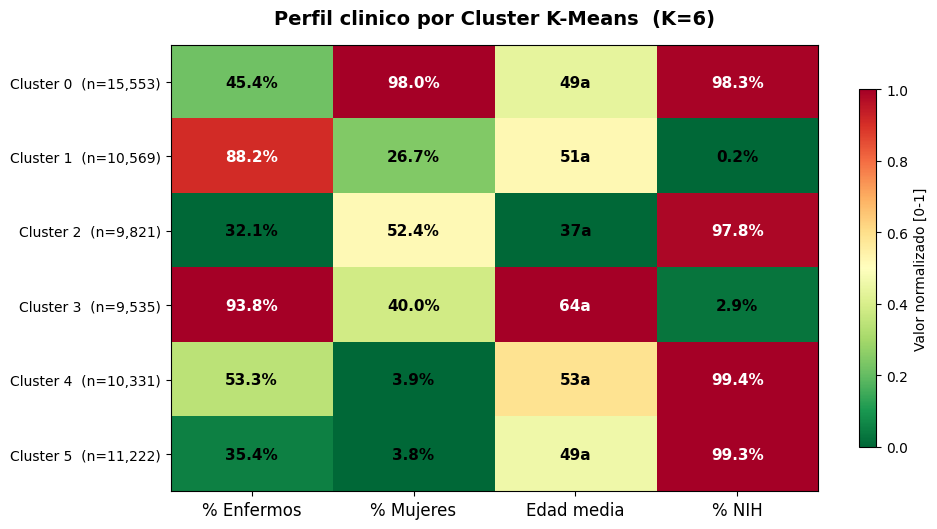

In [16]:
cols_heatmap = ['Pct_enf', 'Pct_F', 'Edad_media', 'Pct_NIH']
labels_hm    = ['% Enfermos', '% Mujeres', 'Edad media', '% NIH']

matriz      = df_resumen_km[cols_heatmap].values.astype(float)
matriz_norm = (matriz - matriz.min(axis=0)) / (matriz.max(axis=0) - matriz.min(axis=0) + 1e-8)

fig, ax = plt.subplots(figsize=(10, max(4, K_OPTIMO * 0.9)))
im = ax.imshow(matriz_norm, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(labels_hm)))
ax.set_xticklabels(labels_hm, fontsize=12)
ax.set_yticks(range(K_OPTIMO))
ax.set_yticklabels([f'Cluster {k}  (n={df_resumen_km["N"].iloc[k]:,})' for k in range(K_OPTIMO)],
                   fontsize=10)

# Valores reales dentro de cada celda
for i in range(K_OPTIMO):
    for j, col in enumerate(cols_heatmap):
        val = df_resumen_km[col].iloc[i]
        fmt = f'{val:.0f}a' if col == 'Edad_media' else f'{val:.1f}%'
        ax.text(j, i, fmt, ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if matriz_norm[i, j] > 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Valor normalizado [0-1]', shrink=0.8)
ax.set_title(f'Perfil clinico por Cluster K-Means  (K={K_OPTIMO})',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(str(RUTA_RESULTADOS / 'kmeans_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Celda 16 — Radiografías prototipo por cluster

Muestra las `N_MUESTRAS_RX` radiografías más cercanas al centroide de cada cluster.
Estas son las imágenes "más representativas" de cada grupo.

Si un cluster tiene menos imágenes que `N_MUESTRAS_RX`, los cuadros sobrantes
muestran **N/D** en lugar de quedar en blanco.

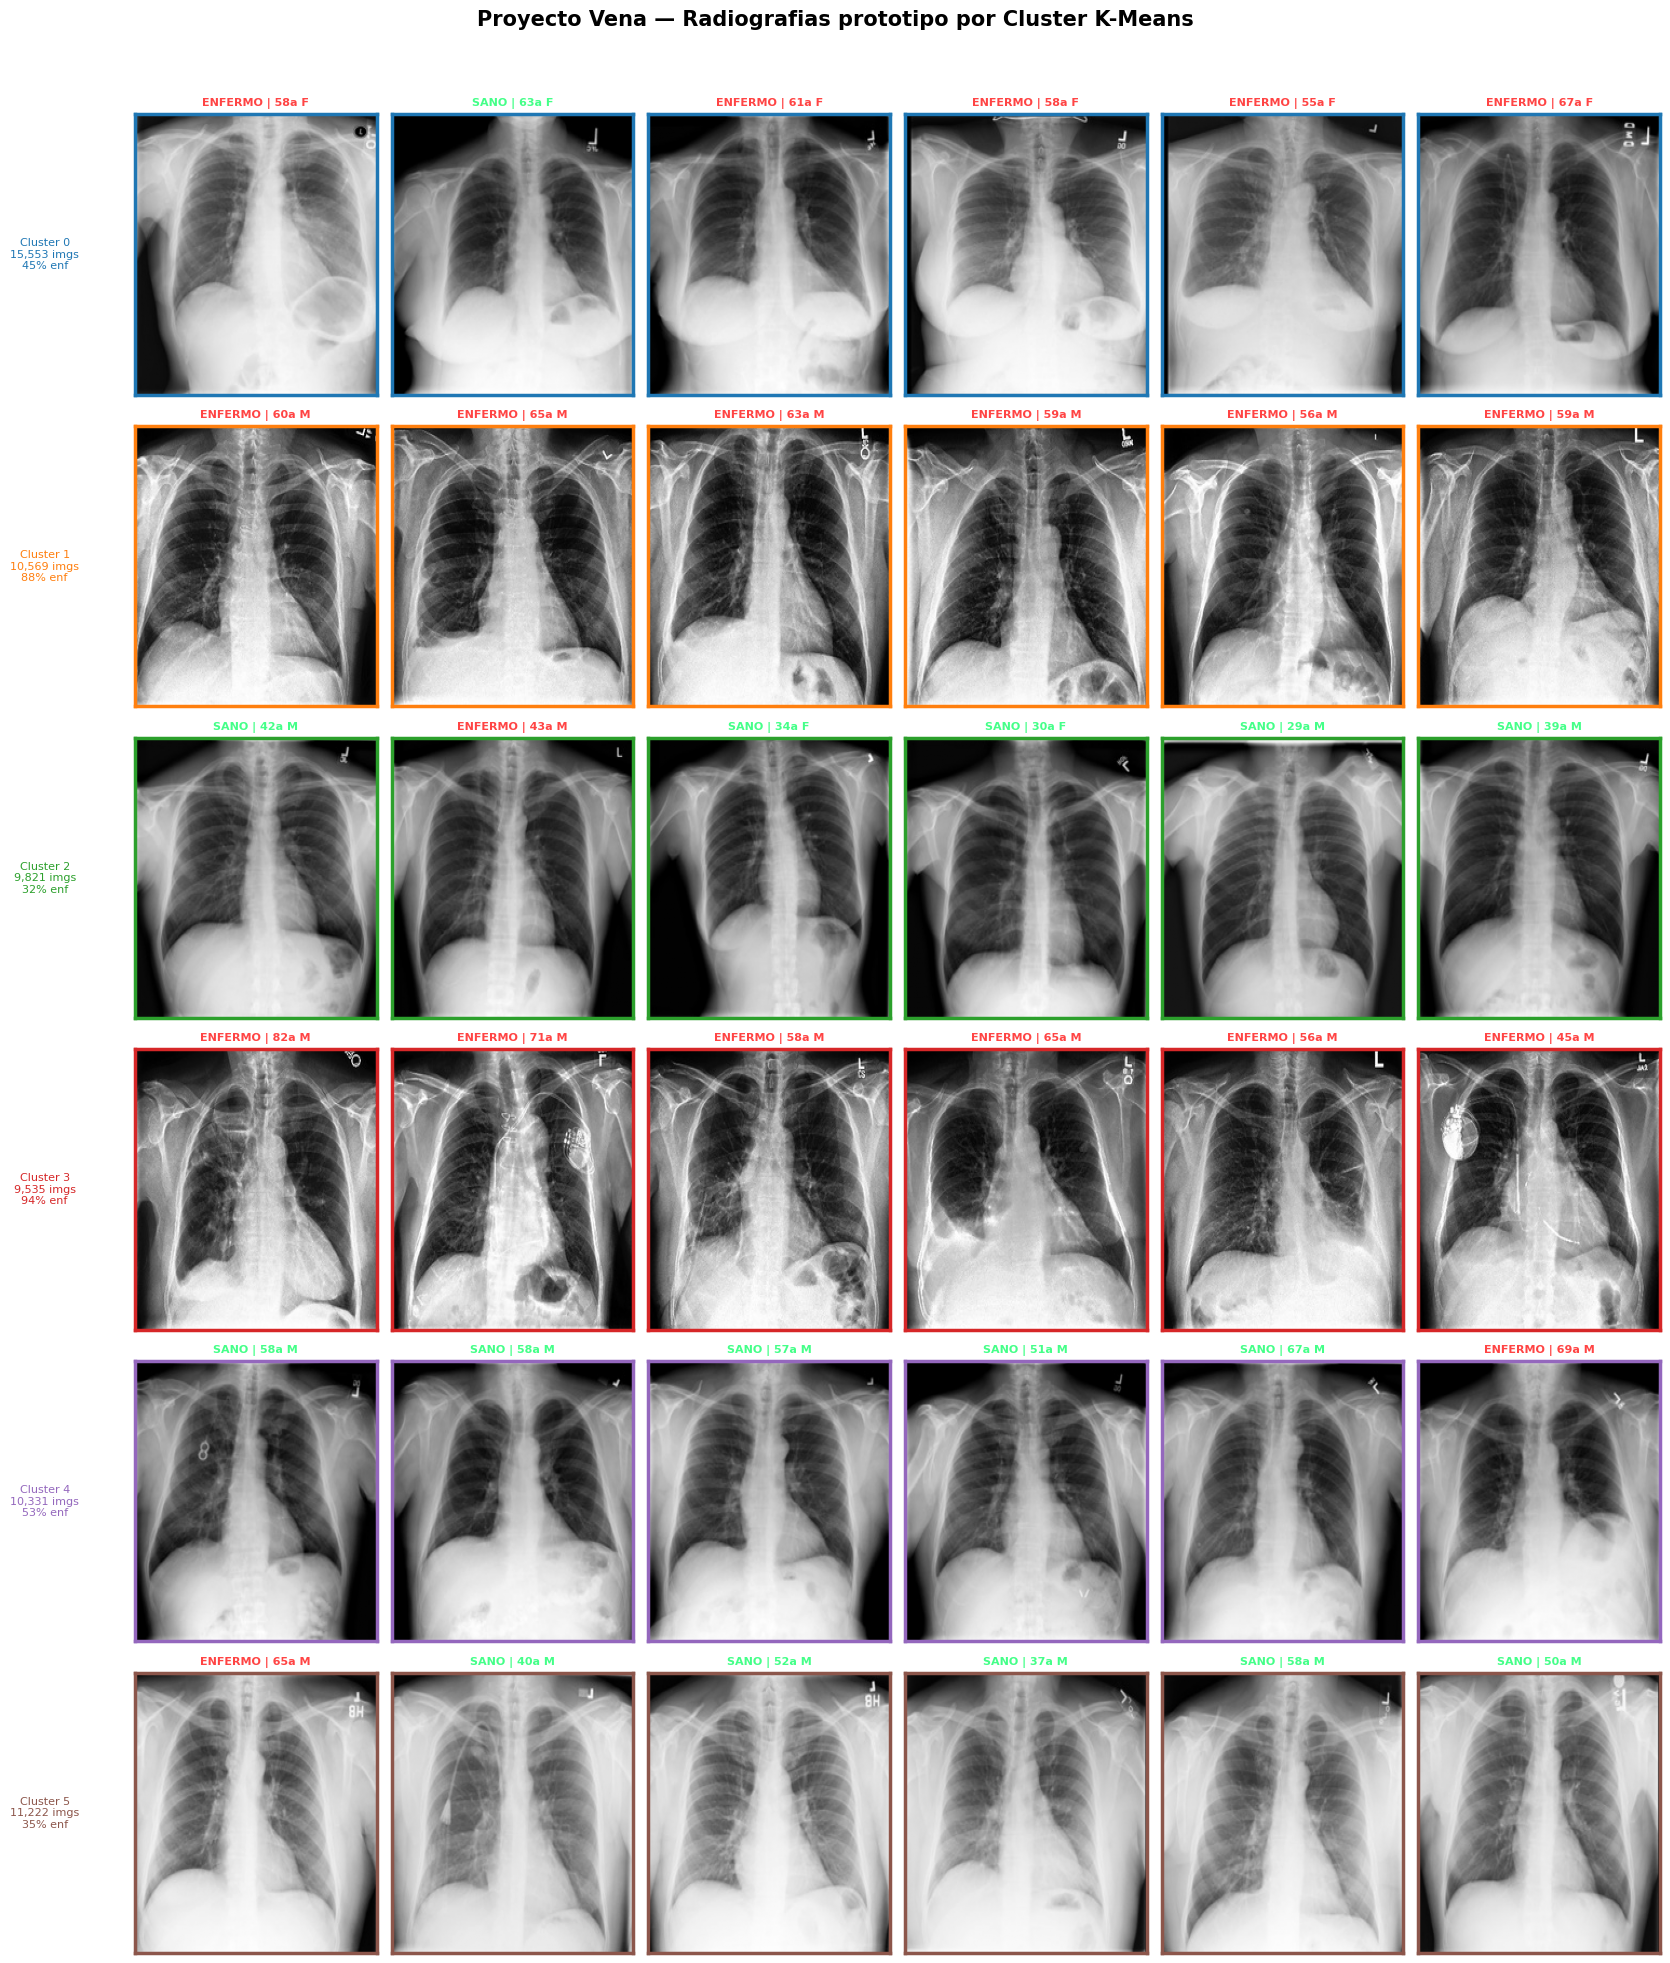

Guardado: kmeans_rx_por_cluster.png


In [17]:
def mostrar_rx_por_cluster(df, col_cluster, titulo_general, nombre_archivo):
    clusters_reales = sorted(df[col_cluster].unique())
    n_rows = len(clusters_reales)
    n_cols = N_MUESTRAS_RX

    if n_rows == 0:
        print('No hay clusters para mostrar.')
        return

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.8, n_rows * 3.2),
                             squeeze=False)
    paleta = sns.color_palette('tab10', n_rows)

    for row, k in enumerate(clusters_reales):
        sub = df[df[col_cluster] == k]

        # Imágenes más cercanas al centroide
        puntos_cluster   = X_pca[sub.index]
        centroide        = puntos_cluster.mean(axis=0)
        distancias       = np.linalg.norm(puntos_cluster - centroide, axis=1)
        indices_ordenados = np.argsort(distancias)[:n_cols]
        muestras         = sub.iloc[indices_ordenados]

        pct_enf     = (sub['label'] == 1).mean() * 100
        color_borde = paleta[row]

        for col in range(n_cols):
            ax = axes[row, col]

            if col < len(muestras):
                fila = muestras.iloc[col]
                try:
                    img = Image.open(fila['ruta_completa']).convert('L')
                    ax.imshow(img, cmap='gray', aspect='auto')
                    estado   = 'ENFERMO' if fila['label'] == 1 else 'SANO'
                    color_st = '#ff4444' if fila['label'] == 1 else '#44ff88'
                    ax.set_title(f"{estado} | {int(fila['patient_age'])}a {fila['patient_gender']}",
                                 fontsize=8, color=color_st, fontweight='bold')
                    for spine in ax.spines.values():
                        spine.set_edgecolor(color_borde)
                        spine.set_linewidth(2.5)
                except Exception:
                    ax.set_facecolor('#1a1a1a')
                    ax.text(0.5, 0.5, 'ERROR', transform=ax.transAxes,
                            ha='center', va='center', fontsize=10,
                            color='#ff4444', fontweight='bold')
            else:
                # Cuadro N/D — cluster con menos imágenes que N_MUESTRAS_RX
                ax.set_facecolor('#1a1a1a')
                ax.text(0.5, 0.5, 'N/D', transform=ax.transAxes,
                        ha='center', va='center', fontsize=16,
                        fontweight='bold', color='#555555')
                for spine in ax.spines.values():
                    spine.set_edgecolor(color_borde)
                    spine.set_linewidth(2.5)

            ax.set_xticks([])
            ax.set_yticks([])

        axes[row, 0].set_ylabel(
            f'Cluster {k}\n{len(sub):,} imgs\n{pct_enf:.0f}% enf',
            fontsize=8, rotation=0, labelpad=65, va='center', color=color_borde
        )

    fig.suptitle(titulo_general, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(RUTA_RESULTADOS / nombre_archivo), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {nombre_archivo}')


# ── Ejecutar para K-Means ────────────────────────────────────────────────────
plt.close('all')
mostrar_rx_por_cluster(
    df,
    col_cluster    = 'cluster_kmeans',
    titulo_general = 'Proyecto Vena — Radiografias prototipo por Cluster K-Means',
    nombre_archivo = 'kmeans_rx_por_cluster.png'
)

## Celda 17 — Distribución clínica por cluster (gráfica de barras)

Panel de barras apiladas que muestra la composición de cada cluster
en términos de diagnóstico, género y rango de edad.

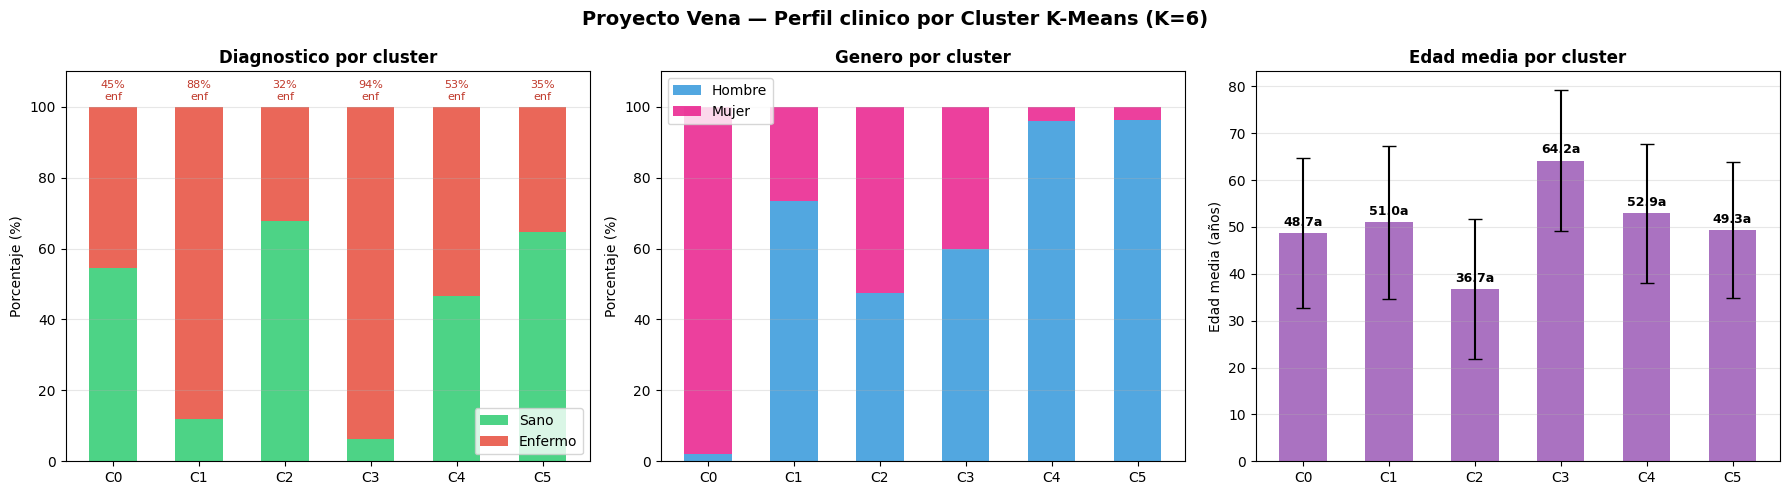

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clusters  = [f'C{k}' for k in range(K_OPTIMO)]
x         = np.arange(K_OPTIMO)
w         = 0.55

# ── Diagnóstico ──────────────────────────────────────────────────────────────
sanos    = df_resumen_km['Pct_sano'].values
enfermos = df_resumen_km['Pct_enf'].values
axes[0].bar(x, sanos,    w, label='Sano',    color='#2ecc71', alpha=0.85)
axes[0].bar(x, enfermos, w, label='Enfermo', color='#e74c3c', alpha=0.85, bottom=sanos)
axes[0].set_xticks(x); axes[0].set_xticklabels(clusters)
axes[0].set_ylabel('Porcentaje (%)'); axes[0].set_ylim(0, 110)
axes[0].set_title('Diagnostico por cluster', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
for i in range(K_OPTIMO):
    axes[0].text(i, 102, f'{enfermos[i]:.0f}%\nenf', ha='center', fontsize=8, color='#c0392b')

# ── Género ───────────────────────────────────────────────────────────────────
pct_m = df_resumen_km['Pct_M'].values
pct_f = df_resumen_km['Pct_F'].values
axes[1].bar(x, pct_m, w, label='Hombre', color='#3498db', alpha=0.85)
axes[1].bar(x, pct_f, w, label='Mujer',  color='#e91e8c', alpha=0.85, bottom=pct_m)
axes[1].set_xticks(x); axes[1].set_xticklabels(clusters)
axes[1].set_ylabel('Porcentaje (%)'); axes[1].set_ylim(0, 110)
axes[1].set_title('Genero por cluster', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

# ── Edad media ───────────────────────────────────────────────────────────────
edades = df_resumen_km['Edad_media'].values
stds   = df_resumen_km['Edad_std'].values
bars   = axes[2].bar(x, edades, w, color='#9b59b6', alpha=0.85,
                     yerr=stds, capsize=5, error_kw={'linewidth': 1.5})
axes[2].set_xticks(x); axes[2].set_xticklabels(clusters)
axes[2].set_ylabel('Edad media (años)')
axes[2].set_title('Edad media por cluster', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, edad in zip(bars, edades):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{edad:.1f}a', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Proyecto Vena — Perfil clinico por Cluster K-Means (K={K_OPTIMO})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RUTA_RESULTADOS / 'kmeans_perfil_clinico.png'), dpi=150, bbox_inches='tight')
plt.show()

## Celda 18 — Exportar modelos para integración

Guarda todos los modelos necesarios para que el compañero que integre
`evaluar_radiografia()` pueda:
1. Preprocesar una nueva imagen igual que aquí (scaler + pca)
2. Predecir a qué cluster pertenece (kmeans)
3. Posicionarla en el mapa UMAP 2D (umap_model)

In [19]:
modelos_path = RUTA_RESULTADOS / 'modelos_produccion'
modelos_path.mkdir(exist_ok=True)

joblib.dump(kmeans, modelos_path / 'v_kmeans_model.joblib')
joblib.dump(scaler, modelos_path / 'v_scaler.joblib')
joblib.dump(pca,    modelos_path / 'v_pca_reducer.joblib')

if reducer is not None:
    joblib.dump(reducer, modelos_path / 'v_umap_model.joblib')
    print('v_umap_model.joblib guardado.')
else:
    print('Nota: modelo UMAP no disponible (fue cargado desde .npy, no re-entrenado).')

# Guardar también el resumen de clusters como referencia
df_resumen_km.to_csv(modelos_path / 'v_kmeans_resumen_clusters.csv', index=False)

print(f'\nModelos exportados en: {modelos_path}')
print()
print('Uso en evaluar_radiografia():')
print('  scaler  = joblib.load(\'v_scaler.joblib\')')
print('  pca     = joblib.load(\'v_pca_reducer.joblib\')')
print('  kmeans  = joblib.load(\'v_kmeans_model.joblib\')')
print('  reducer = joblib.load(\'v_umap_model.joblib\')')
print()
print('  emb_scaled = scaler.transform(embedding.reshape(1, -1))')
print('  x_pca      = pca.transform(emb_scaled)')
print('  cluster    = kmeans.predict(x_pca)[0]')
print('  umap_xy    = reducer.transform(x_pca)[0]')

v_umap_model.joblib guardado.

Modelos exportados en: /home/user/checkpoints/agrupacion/modelos_produccion

Uso en evaluar_radiografia():
  scaler  = joblib.load('v_scaler.joblib')
  pca     = joblib.load('v_pca_reducer.joblib')
  kmeans  = joblib.load('v_kmeans_model.joblib')
  reducer = joblib.load('v_umap_model.joblib')

  emb_scaled = scaler.transform(embedding.reshape(1, -1))
  x_pca      = pca.transform(emb_scaled)
  cluster    = kmeans.predict(x_pca)[0]
  umap_xy    = reducer.transform(x_pca)[0]


## Celda 19 — Resumen final y archivos generados

In [20]:
print('=' * 60)
print('NOTEBOOK 03 — AGRUPACION COMPLETADO')
print('=' * 60)
print(f'\nDataset utilizado      : {len(df):,} radiografias (master_train.csv)')
print(f'Embeddings             : {embeddings.shape[1]} dimensiones por imagen')
print(f'PCA                    : {N_PCA} componentes ({varianza*100:.1f}% varianza)')
print(f'K-Means K optimo       : {K_OPTIMO}')
print(f'Silhouette Score       : {sil_km:.4f}')
print(f'Davies-Bouldin         : {db_km:.4f}')
print(f'\nArchivos generados en  : {RUTA_RESULTADOS}')
print()
for archivo in sorted(RUTA_RESULTADOS.rglob('*')):
    if archivo.is_file():
        tam = archivo.stat().st_size / 1024
        unidad = 'KB' if tam < 1024 else 'MB'
        tam = tam if tam < 1024 else tam / 1024
        nombre_rel = archivo.relative_to(RUTA_RESULTADOS)
        print(f'  {str(nombre_rel):<50} {tam:>6.1f} {unidad}')

print()
print('Para subir al bucket:')
print('gsutil -m cp -r /home/user/checkpoints/agrupacion/ gs://vena-dataset/resultados_agrupacion/')

NOTEBOOK 03 — AGRUPACION COMPLETADO

Dataset utilizado      : 67,031 radiografias (master_train.csv)
Embeddings             : 1024 dimensiones por imagen
PCA                    : 64 componentes (67.5% varianza)
K-Means K optimo       : 6
Silhouette Score       : 0.0538
Davies-Bouldin         : 3.2579

Archivos generados en  : /home/user/checkpoints/agrupacion

  embeddings_train.npy                                261.8 MB
  kmeans_heatmap.png                                  104.0 KB
  kmeans_perfil_clinico.png                            86.2 KB
  kmeans_resumen.csv                                    1.1 KB
  kmeans_rx_por_cluster.png                             3.3 MB
  kmeans_seleccion_k.png                              122.5 KB
  modelos_produccion/v_kmeans_model.joblib            265.8 KB
  modelos_produccion/v_kmeans_resumen_clusters.csv      1.1 KB
  modelos_produccion/v_pca_reducer.joblib             523.4 KB
  modelos_produccion/v_scaler.joblib                   24.6 KB
  model